## 0. Importar librerías


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print('✅ Librerías importadas')

✅ Librerías importadas


## 1. Cargar y limpiar el dataset


In [2]:
df = pd.read_csv(r"D:\The bridge\DS-Online-Hugo-Sanz\04_Machine_Learning\Sprint_10\Unidad_02_ML_Supervisado_Clasificacion_Regresion_Logistica\03_Practica_Obligatoria\data\titanic.csv")
print(f'Tamaño original: {df.shape}')
df.head()

Tamaño original: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Columnas redundantes o inútiles para el modelo
cols_drop = ['alive',        # duplicado de survived (en texto)
             'who',           # derivado de sex + age
             'adult_male',    # derivado de sex + age
             'deck',          # 77% nulos, demasiado para imputar
             'embark_town',   # duplicado de embarked (en texto)
             'alone',         # derivado de sibsp + parch
             'class']         # duplicado de pclass (en texto)

df = df.drop(columns=cols_drop)

print('Columnas que usaremos:', df.columns.tolist())
print()
print('Nulos restantes:')
print(df.isnull().sum())

Columnas que usaremos: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

Nulos restantes:
survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64


**Decisión:** Hay 177 nulos en `age` y 2 en `embarked`.
- Los 2 nulos de `embarked` los eliminamos ahora (son tan pocos que no importa).
- Los nulos de `age` los **imputaremos después del split** con la media de train (para no filtrar información).


In [4]:
# Eliminar las 2 filas con embarked nulo
df = df.dropna(subset=['embarked'])
print(f'Filas tras eliminar nulos en embarked: {len(df)}')

Filas tras eliminar nulos en embarked: 889


## 2. Analizar el target: Survived
El target es binario: 0 = no sobrevivió, 1 = sobrevivió.
Es importante saber si las clases están **desbalanceadas**, porque eso afecta al modelo.


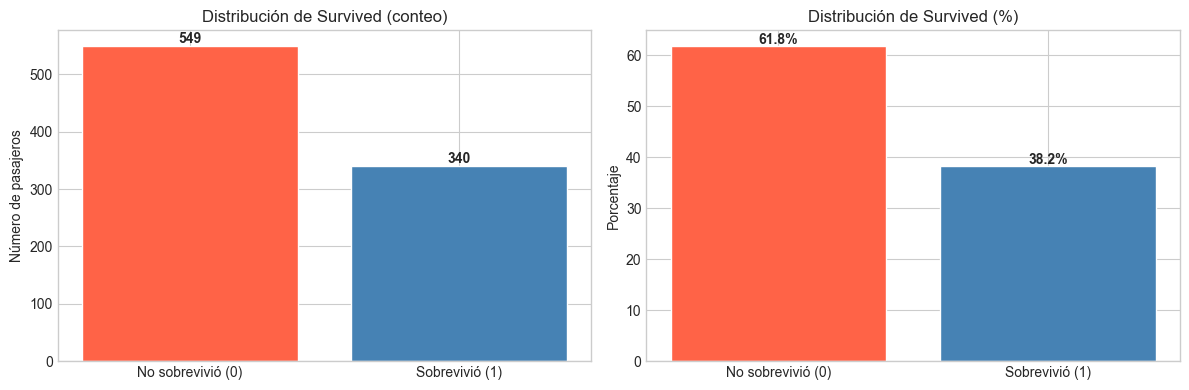

Supervivientes: 340 (38.2%)
No supervivientes: 549 (61.8%)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo absoluto
counts = df['survived'].value_counts()
axes[0].bar(['No sobrevivió (0)', 'Sobrevivió (1)'], counts.values,
            color=['tomato', 'steelblue'], edgecolor='white')
axes[0].set_title('Distribución de Survived (conteo)')
axes[0].set_ylabel('Número de pasajeros')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Porcentaje
pct = df['survived'].value_counts(normalize=True) * 100
axes[1].bar(['No sobrevivió (0)', 'Sobrevivió (1)'], pct.values,
            color=['tomato', 'steelblue'], edgecolor='white')
axes[1].set_title('Distribución de Survived (%)')
axes[1].set_ylabel('Porcentaje')
for i, v in enumerate(pct.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Supervivientes: {counts[1]} ({pct[1]:.1f}%)')
print(f'No supervivientes: {counts[0]} ({pct[0]:.1f}%)')

**Interpretación:** Las clases están algo desbalanceadas (~38% sobrevivió vs ~62% no sobrevivió).
No es un desbalance extremo, pero significa que un modelo tonto que siempre prediga 'no sobrevive'
acertaría el 62% de las veces. Nuestro modelo tiene que hacerlo **mejor que eso**.


## 3. Split Train/Test estratificado por ciudad de embarque
El enunciado pide que ambos conjuntos tengan un **reparto similar de ciudades de embarque**.
Para eso usamos `stratify=df['embarked']`.


In [6]:
X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=df['embarked']   # ← asegura mismo % de S/C/Q en train y test
)

print(f'Train: {len(X_train)} pasajeros')
print(f'Test:  {len(X_test)} pasajeros')
print()
print('Distribución de embarked en train:')
print(X_train['embarked'].value_counts(normalize=True).round(2))
print()
print('Distribución de embarked en test:')
print(X_test['embarked'].value_counts(normalize=True).round(2))

Train: 711 pasajeros
Test:  178 pasajeros

Distribución de embarked en train:
embarked
S    0.72
C    0.19
Q    0.09
Name: proportion, dtype: float64

Distribución de embarked en test:
embarked
S    0.72
C    0.19
Q    0.08
Name: proportion, dtype: float64


## 4. Imputar nulos


In [7]:
# Calcular medias y modas SOLO en train
age_mean = X_train['age'].mean()
fare_mean = X_train['fare'].mean()

print(f'Media de edad en train: {age_mean:.1f} años')

# Imputar en train
X_train = X_train.copy()
X_train['age'] = X_train['age'].fillna(age_mean)
X_train['fare'] = X_train['fare'].fillna(fare_mean)

# Aplicar los MISMOS valores al test
X_test = X_test.copy()
X_test['age'] = X_test['age'].fillna(age_mean)
X_test['fare'] = X_test['fare'].fillna(fare_mean)

print('Nulos en train tras imputar:', X_train.isnull().sum().sum())
print('Nulos en test tras imputar:', X_test.isnull().sum().sum())

Media de edad en train: 29.7 años
Nulos en train tras imputar: 0
Nulos en test tras imputar: 0


## 5. Mini-EDA: ¿Qué variables influyen en la supervivencia?


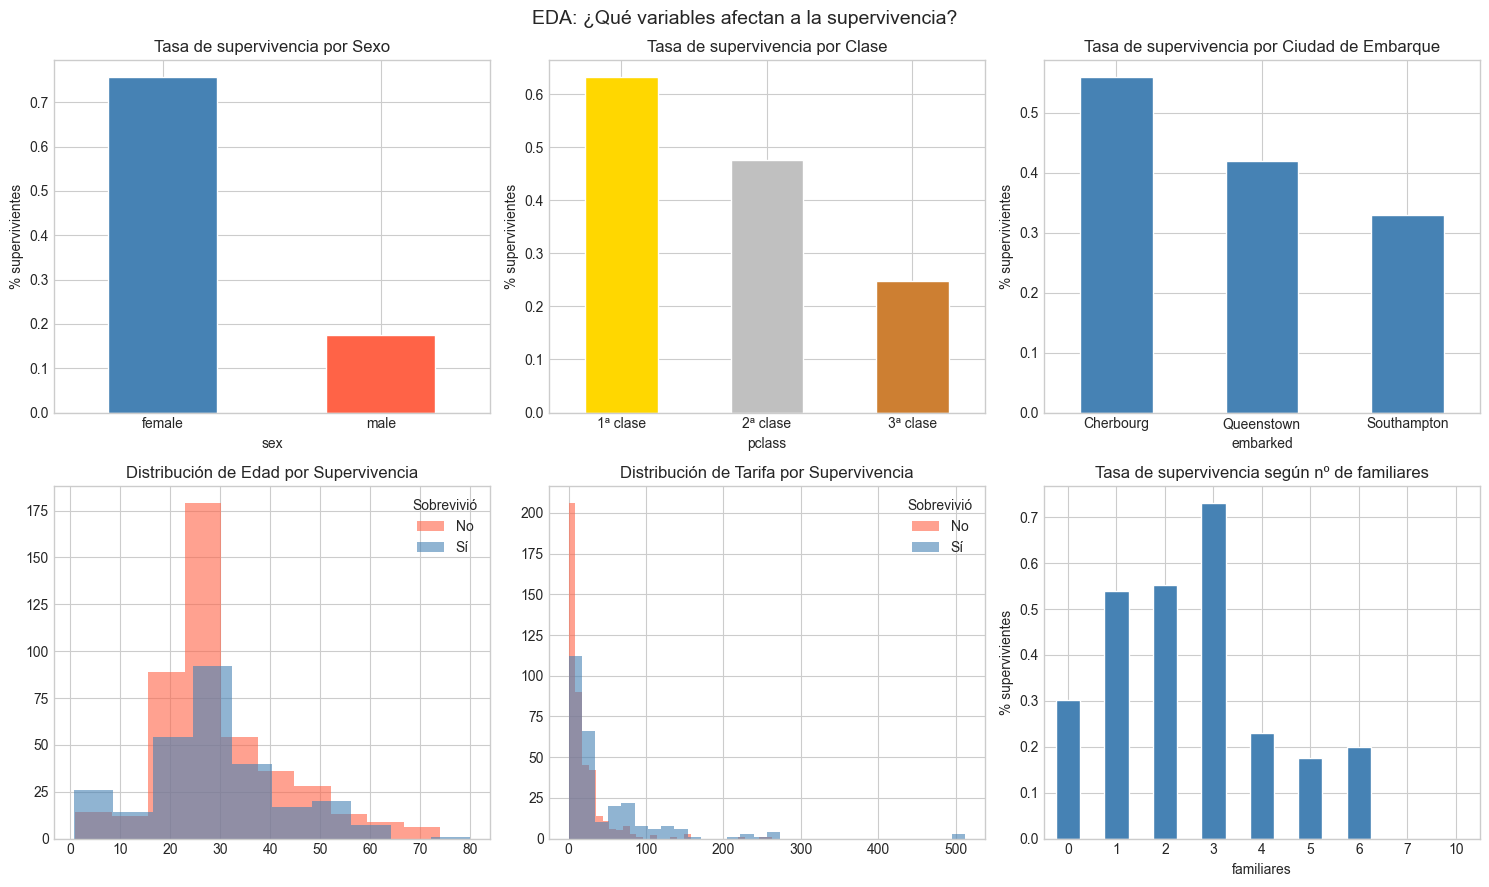

In [8]:
# Usamos X_train + y_train para el EDA (no tocamos test)
df_eda = X_train.copy()
df_eda['survived'] = y_train.values

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Supervivencia por sexo
df_eda.groupby('sex')['survived'].mean().plot(kind='bar', ax=axes[0,0],
    color=['steelblue', 'tomato'], edgecolor='white')
axes[0,0].set_title('Tasa de supervivencia por Sexo')
axes[0,0].set_ylabel('% supervivientes')
axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=0)

# Supervivencia por clase
df_eda.groupby('pclass')['survived'].mean().plot(kind='bar', ax=axes[0,1],
    color=['gold', 'silver', '#cd7f32'], edgecolor='white')
axes[0,1].set_title('Tasa de supervivencia por Clase')
axes[0,1].set_ylabel('% supervivientes')
axes[0,1].set_xticklabels(['1ª clase', '2ª clase', '3ª clase'], rotation=0)

# Supervivencia por embarque
df_eda.groupby('embarked')['survived'].mean().plot(kind='bar', ax=axes[0,2],
    color='steelblue', edgecolor='white')
axes[0,2].set_title('Tasa de supervivencia por Ciudad de Embarque')
axes[0,2].set_ylabel('% supervivientes')
axes[0,2].set_xticklabels(['Cherbourg', 'Queenstown', 'Southampton'], rotation=0)

# Distribución de edad por supervivencia
df_eda[df_eda['survived']==0]['age'].hist(ax=axes[1,0], alpha=0.6, color='tomato', label='No')
df_eda[df_eda['survived']==1]['age'].hist(ax=axes[1,0], alpha=0.6, color='steelblue', label='Sí')
axes[1,0].set_title('Distribución de Edad por Supervivencia')
axes[1,0].legend(title='Sobrevivió')

# Distribución de fare por supervivencia
df_eda[df_eda['survived']==0]['fare'].hist(ax=axes[1,1], alpha=0.6, color='tomato', bins=30, label='No')
df_eda[df_eda['survived']==1]['fare'].hist(ax=axes[1,1], alpha=0.6, color='steelblue', bins=30, label='Sí')
axes[1,1].set_title('Distribución de Tarifa por Supervivencia')
axes[1,1].legend(title='Sobrevivió')

# Familiares a bordo
df_eda['familiares'] = df_eda['sibsp'] + df_eda['parch']
df_eda.groupby('familiares')['survived'].mean().plot(kind='bar', ax=axes[1,2],
    color='steelblue', edgecolor='white')
axes[1,2].set_title('Tasa de supervivencia según nº de familiares')
axes[1,2].set_ylabel('% supervivientes')
axes[1,2].set_xticklabels(axes[1,2].get_xticklabels(), rotation=0)

plt.suptitle('EDA: ¿Qué variables afectan a la supervivencia?', fontsize=14)
plt.tight_layout()
plt.show()

**Conclusiones del EDA:**
- **Sexo**: las mujeres sobrevivieron a una tasa mucho mayor (protocolo 'mujeres y niños primero')
- **Clase**: 1ª clase sobrevivió más que 3ª clase (acceso a botes)
- **Tarifa**: quienes pagaron más sobrevivieron más (correlacionado con clase)
- **Familiares**: viajar solo o con demasiada familia reduce la supervivencia

Usaremos: `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked` → **todas las variables disponibles**.


## 6. Encoding y escalado
La regresión logística necesita variables **numéricas** y en la **misma escala**.
- `sex` y `embarked` son categóricas → usamos `get_dummies` (One-Hot Encoding)
- `drop_first=True` evita la multicolinealidad perfecta


In [9]:
# One-Hot Encoding de variables categóricas
X_train_enc = pd.get_dummies(X_train, columns=['sex', 'embarked'], drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  columns=['sex', 'embarked'], drop_first=True)

# Alineamos columnas (por si alguna categoría no aparece en test)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print('Columnas tras encoding:', X_train_enc.columns.tolist())

# Escalar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled  = scaler.transform(X_test_enc)

print('✅ Datos listos para el modelo')

Columnas tras encoding: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q', 'embarked_S']
✅ Datos listos para el modelo


## 7. Entrenar el modelo de Regresión Logística


In [10]:
modelo = LogisticRegression(random_state=42, max_iter=1000)
modelo.fit(X_train_scaled, y_train)

print('✅ Modelo entrenado')

✅ Modelo entrenado


## 8. EXTRA: Importancia de las variables
Los coeficientes del modelo nos dicen cuánto pesa cada variable.
Un coeficiente positivo aumenta la probabilidad de sobrevivir, uno negativo la reduce.


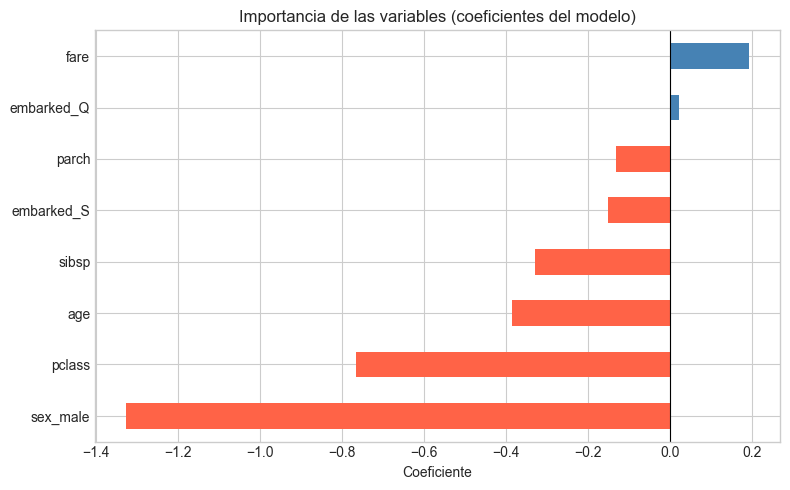

Variables que MÁS aumentan la supervivencia:
parch        -0.130152
embarked_Q    0.021761
fare          0.193046
dtype: float64

Variables que MÁS la reducen:
sex_male   -1.325427
pclass     -0.765569
age        -0.385664
dtype: float64


In [11]:
coefs = pd.Series(modelo.coef_[0], index=X_train_enc.columns).sort_values()

plt.figure(figsize=(8, 5))
coefs.plot(kind='barh', color=['tomato' if c < 0 else 'steelblue' for c in coefs])
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Importancia de las variables (coeficientes del modelo)')
plt.xlabel('Coeficiente')
plt.tight_layout()
plt.show()

print('Variables que MÁS aumentan la supervivencia:')
print(coefs.tail(3))
print('\nVariables que MÁS la reducen:')
print(coefs.head(3))

**Interpretación:**
- `sex_male` tiene un coeficiente muy negativo → ser hombre reduce mucho la probabilidad de sobrevivir
- `pclass` negativo → mayor número de clase (más barata) = menos supervivencia
- `fare` positivo → pagar más (correlacionado con 1ª clase) = más supervivencia


## 9. Evaluar el modelo
Evaluamos en **train y test** para ver si hay overfitting.


In [12]:
y_pred_train = modelo.predict(X_train_scaled)
y_pred_test  = modelo.predict(X_test_scaled)
y_prob_test  = modelo.predict_proba(X_test_scaled)[:, 1]

print('=== Resultados en TRAIN ===')
print(classification_report(y_train, y_pred_train, target_names=['No sobrevive', 'Sobrevive']))

print('=== Resultados en TEST ===')
print(classification_report(y_test, y_pred_test, target_names=['No sobrevive', 'Sobrevive']))

=== Resultados en TRAIN ===
              precision    recall  f1-score   support

No sobrevive       0.82      0.88      0.85       440
   Sobrevive       0.78      0.70      0.74       271

    accuracy                           0.81       711
   macro avg       0.80      0.79      0.79       711
weighted avg       0.81      0.81      0.81       711

=== Resultados en TEST ===
              precision    recall  f1-score   support

No sobrevive       0.80      0.85      0.83       109
   Sobrevive       0.74      0.67      0.70        69

    accuracy                           0.78       178
   macro avg       0.77      0.76      0.76       178
weighted avg       0.78      0.78      0.78       178



**Guía rápida de métricas:**
- **Precision**: de todos los que predije que sobrevivirían, ¿cuántos realmente sobrevivieron?
- **Recall**: de todos los que realmente sobrevivieron, ¿cuántos detecté?
- **F1-score**: media entre precision y recall
- **Accuracy**: % total de predicciones correctas

Si train y test dan resultados similares → el modelo **generaliza bien** (no hay overfitting).


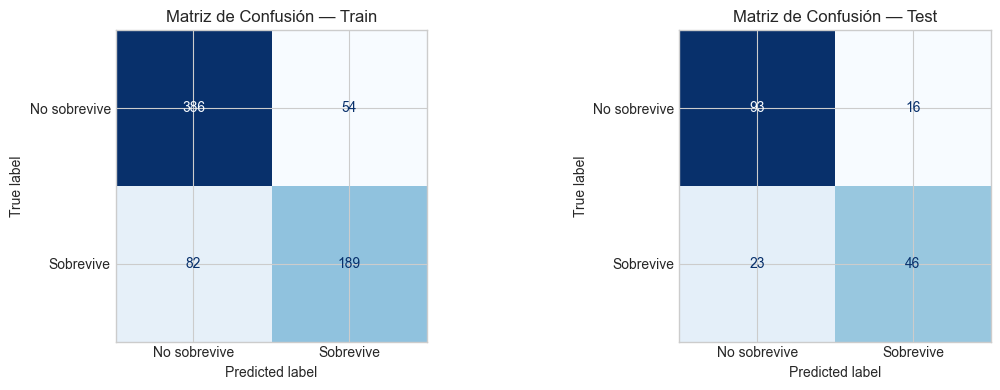

Cómo leer la matriz:
  Diagonal principal = predicciones CORRECTAS
  Fuera de la diagonal = errores


In [13]:
# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (nombre, y_true, y_pred) in zip(axes, [
    ('Train', y_train, y_pred_train),
    ('Test',  y_test,  y_pred_test)
]):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No sobrevive', 'Sobrevive'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de Confusión — {nombre}')

plt.tight_layout()
plt.show()

print('Cómo leer la matriz:')
print('  Diagonal principal = predicciones CORRECTAS')
print('  Fuera de la diagonal = errores')

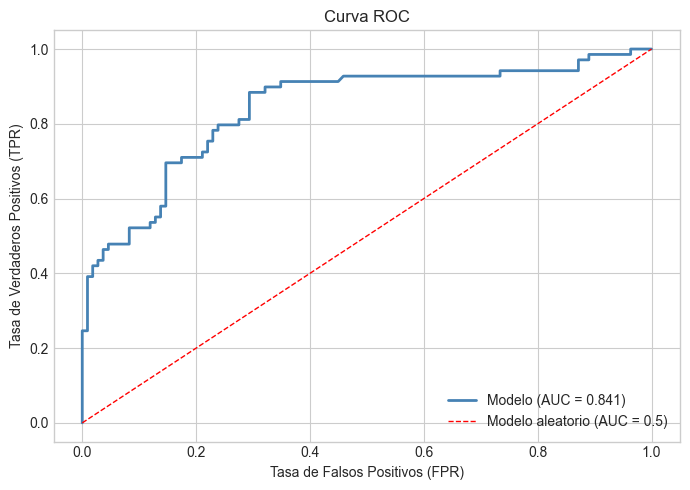

AUC = 0.841
AUC cercano a 1 = muy buen modelo | AUC = 0.5 = modelo aleatorio


In [14]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
auc = roc_auc_score(y_test, y_prob_test)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'Modelo (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Modelo aleatorio (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.tight_layout()
plt.show()

print(f'AUC = {auc:.3f}')
print('AUC cercano a 1 = muy buen modelo | AUC = 0.5 = modelo aleatorio')

**Conclusión de la evaluación:**
- Accuracy ~78% en test (el modelo tonto que siempre dice 'no' sería ~61%) ✅
- AUC ~0.84 → muy buena capacidad discriminativa
- Train y test dan resultados similares → no hay overfitting significativo ✅


## 10. EXTRA: Probabilidad de supervivencia de un pasajero concreto
**Perfil:** hombre, entre 30 y 40 años, 2ª clase, embarcó en Southampton, viajaba solo, no pagó el billete.

Como el enunciado pide calcular varias probabilidades (una por cada edad) y hacer la media:


In [15]:
# Construimos un pasajero para cada edad entre 30 y 40
probabilidades = []

for edad in range(30, 41):
    # Crear fila con el perfil del pasajero
    pasajero = pd.DataFrame({col: [0] for col in X_train_enc.columns})
    pasajero['pclass']    = 2       # 2ª clase
    pasajero['age']       = edad    # edad variable
    pasajero['sibsp']     = 0       # sin pareja ni hermanos
    pasajero['parch']     = 0       # sin hijos ni padres
    pasajero['fare']      = 0       # no pagó
    pasajero['sex_male']  = 1       # hombre
    pasajero['embarked_S'] = 1      # Southampton (la ref es Cherbourg)
    
    # Escalar y predecir
    pasajero_scaled = scaler.transform(pasajero)
    prob = modelo.predict_proba(pasajero_scaled)[0][1]
    probabilidades.append(prob)

prob_media = np.mean(probabilidades)

print(f'Probabilidad de supervivencia promedio (30-40 años): {prob_media:.1%}')
print()
print('Probabilidad por edad:')
for edad, prob in zip(range(30, 41), probabilidades):
    print(f'  {edad} años: {prob:.1%}')

Probabilidad de supervivencia promedio (30-40 años): 19.0%

Probabilidad por edad:
  30 años: 21.3%
  31 años: 20.8%
  32 años: 20.3%
  33 años: 19.9%
  34 años: 19.4%
  35 años: 18.9%
  36 años: 18.5%
  37 años: 18.1%
  38 años: 17.6%
  39 años: 17.2%
  40 años: 16.8%


**Conclusión:** Un hombre de entre 30 y 40 años, en 2ª clase, embarcado en Southampton y viajando solo
tenía aproximadamente un **19% de probabilidad de sobrevivir**. El "mujeres y niños primero" era muy real.


## 11. EXTRA: Modelo multiclase — predecir la clase del billete
Ahora cambiamos el objetivo: en lugar de predecir si sobrevivió, predecimos **en qué clase viajaba** (1ª, 2ª o 3ª).

Según el enunciado:
- Quitamos `pclass` de X
- Añadimos `survived` a X (que antes era el target)
- El nuevo target es `pclass`


In [16]:
# Nuevo target: la clase del pasajero
y_train_mc = X_train['pclass'].values
y_test_mc  = X_test['pclass'].values

# Nuevas X: sin pclass, pero CON survived
X_train_mc = X_train_enc.drop('pclass', axis=1).copy()
X_test_mc  = X_test_enc.drop('pclass', axis=1).copy()

X_train_mc['survived'] = y_train.values
X_test_mc['survived']  = y_test.values

# Escalar con un nuevo scaler
scaler_mc = StandardScaler()
X_train_mc_scaled = scaler_mc.fit_transform(X_train_mc)
X_test_mc_scaled  = scaler_mc.transform(X_test_mc)

# Modelo multiclase
modelo_mc = LogisticRegression(random_state=42, max_iter=1000)
modelo_mc.fit(X_train_mc_scaled, y_train_mc)

# Evaluación
print('=== Clasificación multiclase: predecir Clase del billete ===')
print(classification_report(
    y_test_mc,
    modelo_mc.predict(X_test_mc_scaled),
    target_names=['1ª Clase', '2ª Clase', '3ª Clase']
))

=== Clasificación multiclase: predecir Clase del billete ===
              precision    recall  f1-score   support

    1ª Clase       0.98      0.90      0.94        51
    2ª Clase       0.73      0.27      0.39        41
    3ª Clase       0.72      0.98      0.83        86

    accuracy                           0.79       178
   macro avg       0.81      0.72      0.72       178
weighted avg       0.80      0.79      0.76       178



**Observaciones:**
- **1ª Clase** se predice muy bien (precision/recall altos) — tiene un perfil muy distinto
- **2ª Clase** es la más difícil de distinguir — se solapa con 1ª y 3ª
- **3ª Clase** también se predice bien por su volumen y perfil característico
- La supervivencia (`survived`) es una feature muy informativa para predecir la clase


## Conclusiones finales

| Aspecto | Resultado |
|---|---|
| Accuracy (test) | ~78% |
| AUC-ROC | ~0.84 |
| Variables más importantes | `sex`, `pclass`, `fare` |
| Overfitting | No (train y test similares) |
| Prob. supervivencia hombre 30-40, 2ª clase, solo | ~19% |

**El modelo de regresión logística funciona bien para este problema**, con un AUC de 0.84.
Las variables más determinantes son el sexo, la clase y la tarifa pagada.
Para mejorar, se podría intentar ingeniería de features (extraer el título del nombre, combinar variables familiares) o usar modelos más complejos como Random Forest.
